In [3]:
import sys
import os
sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# Now we can safely import atlasopenmagic
import atlasopenmagic as atom

In [4]:
import uproot # for reading .root files
import time # to measure time to analyse
import math # for mathematical functions such as square root
import awkward as ak # for handling complex and nested data structures efficiently
import numpy as np # # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import vector #to use vectors
import requests # for HTTP access
import aiohttp # HTTP client support
import pandas as pd

In [5]:
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 747.74datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [6]:
lumi = 36

In [25]:
# list with signal DSIDs: ee, mumu
# should tautau, bb, tt be included?
dsid_signal_list = [301209] 
dsid_background_list = [700323, 700324, 700325, 700470, 700471, 700472, 410219, 700589, 700593, 700602, 601624, 601628]
#dsid_background_list = [700324, 700325, 700470, 700471, 700472]

In [ ]:
for dsid in dsid_background_list:
    print(atom.get_metadata(dsid, 'physics_short'))

# are these corect?

Sh_2211_Zmumu_maxHTpTV2_BFilter
Sh_2211_Zmumu_maxHTpTV2_CFilterBVeto
Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto
Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_BFilter
Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_CFilterBVeto
Sh_2211_Zmumu_maxHTpTV2_m10_40_pT5_CVetoBVeto
aMcAtNloPythia8EvtGen_MEN30NLO_A14N23LO_ttmumu
Sh_2212_llvvjj_os
Sh_2212_llvvjj_os_Int
Sh_2212_llvv_os
PhPy8EG_tW_DS_dyn_dil_antitop
PhPy8EG_tW_DS_dyn_dil_top


In [8]:
def get_xsec_weight(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
        / metadata["sumOfWeights"]
    )

def get_N_inclusive(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
    )

def get_inclusive_yield(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
    )

def calc_weight(xsec_weight, weight_arr, data):
    for variable in weight_arr:
        xsec_weight = xsec_weight * data[variable]
    return xsec_weight

In [9]:
# functions to use at the start or end of a working session
# save current df as hdf5 or load saved hdf5 as df
def save_df(df_variables, df_labels, filename="blackbox_final.h5"):

    print(f"Saving DataFrame to {filename} ...")

    with pd.HDFStore(filename, mode="w") as store:
        store["variables"] = df_variables
        store["labels"] = df_labels

    print(f"Saved {len(df_variables)} events " f"to {filename}")


def load_df(filename="blackbox_final.h5"):

    if not os.path.exists(filename):
        raise FileNotFoundError(f"No HDF5 file found: {filename}")

    print(f"Loading DataFrame from {filename} ...")

    with pd.HDFStore(filename, mode="r") as store:
        df_variables = store["variables"]
        df_labels = store["labels"]

    print(f"Loaded {len(df_variables)} events " f"from {filename}")

    return df_variables, df_labels

In [26]:
def events_to_dataframe(data, variables, max_entries, default_values, label):

    result = {}

    for variable in variables:

        values = data[variable]

        # max entries for this variable
        n = max_entries[variable]

        # expand, cut to n entries
        values = ak.pad_none(values, n, clip=True)

        # replace missing entries with default value
        values = ak.fill_none(values, default_values[variable])

        # new column for each position
        for i in range(n):
            result[f"{variable}{i+1}"] = ak.to_numpy(values[:, i])

    # label
    result["label"] = label

    return pd.DataFrame(result)

In [10]:
# number of signal events, might be scaled up
metadata = atom.get_metadata(dsid_signal_list[0])
xsec_weight = get_xsec_weight(metadata, lumi)
signal_nevents = get_N_inclusive(metadata, lumi)
signal_nevents

63.784800000000004

In [11]:
background_yield_sum = 0
for dsid in dsid_background_list:
    metadata = atom.get_metadata(dsid)
    inc_yield = get_inclusive_yield(metadata, lumi)
    background_yield_sum = background_yield_sum + inc_yield

background_yield_sum

169552006.268292

In [64]:
variables = ["lep_pt", "lep_eta", "lep_phi", "lep_e", "jet_pt", "jet_eta", "jet_phi",]

max_entries = {"lep_pt": 4, "lep_eta": 4, "lep_phi": 4, "lep_e": 4, "jet_pt": 4, "jet_eta": 4, "jet_phi": 4,}

default_values = {"lep_pt": 0.0, "lep_eta": 0.0, "lep_phi": 0.0, "lep_e": 0.0, "jet_pt": 0.0, "jet_eta": 0.0, "jet_phi": 0.0,}

In [56]:
def create_blackbox(signal_dsid_list, background_dsid_list, variables, max_entries, default_values, signal_nevents, background_nevents, 
                    skim="noskim", checkpoint_file="blackbox.h5"):

    if os.path.exists(checkpoint_file):
        print(f"Load checkpoint: {checkpoint_file}")

        df = pd.read_hdf(checkpoint_file, key="events")

        checkpoint_info = pd.read_hdf(checkpoint_file, key="completed_dsid")

        completed_dsids = set(checkpoint_info["dsid"].astype(str))

        print(f"{len(df)} events loaded from checkpoint.")
        print(f"{len(completed_dsids)} DSIDs already processed.")
        print(f"Completed DSIDs: {completed_dsids}")


    else:

        print("No checkpoint found. Start from scratch.")

        # create empty DataFrame with the required columns
        columns = []

        for variable in variables:
            n = max_entries[variable]

            for i in range(n):
                columns.append(f"{variable}{i+1}")

        columns.append("label")

        df = pd.DataFrame({column: pd.Series(dtype="float64") for column in columns})

        df["label"] = pd.Series(dtype="int8")

        completed_dsids = set()

        print(f"Created empty DataFrame with columns:")
        print(df.columns.tolist())

    # calculate inclusive yield for each dsid
    yield_dict = {}
    signal_yield_sum = 0
    background_yield_sum = 0

    for dsid in signal_dsid_list:
        metadata = atom.get_metadata(dsid)
        inc_yield = get_inclusive_yield(metadata, lumi)
        yield_dict[dsid] = inc_yield
        signal_yield_sum = signal_yield_sum + inc_yield

    for dsid in background_dsid_list:
        metadata = atom.get_metadata(dsid)
        inc_yield = get_inclusive_yield(metadata, lumi)
        yield_dict[dsid] = inc_yield
        background_yield_sum = background_yield_sum + inc_yield


    def save_checkpoint():

        print("Save checkpoint ...")

        df.to_hdf(checkpoint_file, key="events", mode="w", format="table")

        completed_df = pd.DataFrame({"dsid": [str(dsid) for dsid in completed_dsids]})

        completed_df.to_hdf(checkpoint_file, key="completed_dsid", mode="a", format="table")

        print(f"Checkpoint saved: " f"{len(df)} Events, " f"{len(completed_dsids)} DSIDs")


    # calculate number of events for the blackbox for each dsid
    nevents_per_sample_dict = {}

    for dsid in signal_dsid_list:
        nevents_per_sample = signal_nevents / signal_yield_sum * yield_dict[dsid]
        nevents_per_sample_dict[dsid] = nevents_per_sample

    for dsid in background_dsid_list:
        nevents_per_sample = background_nevents / background_yield_sum * yield_dict[dsid]
        nevents_per_sample_dict[dsid] = nevents_per_sample

    # create blackbox
    for dsid, label in [(dsid, 1) for dsid in signal_dsid_list] + [(dsid, 0) for dsid in background_dsid_list]:

            dsid_str = str(dsid)

            print(f"\nCurrent DSID: {dsid}")
            print(f"Already processed: {dsid_str in completed_dsids}")

            if dsid_str in completed_dsids:
                print(f"DSID {dsid} already processed -> SKIP")
                continue
            
            target_events = int(nevents_per_sample_dict[dsid])
            remaining = target_events
            collected_events = 0
    
            file_list = atom.get_urls(dsid, skim, protocol='root', cache=False)
            print("filelist: ", file_list)
    
            #for url in atom.get_urls(dsid, protocol='root', cache=True):
            #    print("url: ", url)

            for afile in file_list:
                # Print which sample is being processed
                print(f'Processing file {afile} ({file_list.index(afile)+1}/{len(file_list)})')
                #print("afile: ", f'{afile}')
                print("target events: ", target_events)
    
                # Open file
                # tree = uproot.open(afile + ":analysis")
                #print("The information stored in the tree is:", tree.keys())
                # print("tree opened")

                # for data in tree.iterate(variables, library="ak", step_size=1000):
                for data in uproot.iterate(afile + ":analysis", variables, library="ak", step_size=1000):

                    # data = data[ak.num(data.lep_pt) == 2]

                    if len(data) == 0:
                        continue

                    if len(data) > remaining:
                        data = data[:remaining]


                    new_df = events_to_dataframe(data, variables, max_entries, default_values, label)

                    df = pd.concat([df, new_df], ignore_index=True)

                    collected_events += len(new_df)
                    remaining = target_events - collected_events

                    print("collected events: ", collected_events)
                    if collected_events >= target_events:
                        break
                    
                if collected_events >= target_events:
                    break

            completed_dsids.add(dsid_str)

            save_checkpoint()


    # shuffel the data frame
    df = df.sample(frac=1, random_state=25).reset_index(drop=True)

    # split df into variables and labels
    df_variables = df.drop(columns=["label"])
    df_labels = df["label"]

    return df_variables, df_labels

In [65]:
df_var, df_lab = create_blackbox(dsid_signal_list, dsid_background_list, variables, max_entries, default_values, 1000, 8000, skim="2muons")
print("var: ", df_var)
print("lab: ", df_lab)

No checkpoint found. Start from scratch.
Created empty DataFrame with columns:
['lep_pt1', 'lep_pt2', 'lep_pt3', 'lep_pt4', 'lep_eta1', 'lep_eta2', 'lep_eta3', 'lep_eta4', 'lep_phi1', 'lep_phi2', 'lep_phi3', 'lep_phi4', 'lep_e1', 'lep_e2', 'lep_e3', 'lep_e4', 'jet_pt1', 'jet_pt2', 'jet_pt3', 'jet_pt4', 'jet_eta1', 'jet_eta2', 'jet_eta3', 'jet_eta4', 'jet_phi1', 'jet_phi2', 'jet_phi3', 'jet_phi4', 'label']

Current DSID: 301209
Already processed: False
filelist:  ['root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_301209.Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000.2muons.root']
Processing file root://eospublic.cern.ch:1094//eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2muons_mc_301209.Pythia8EvtGen_A14MSTW2008LO_Zprime_NoInt_mumu_SSM3000.2muons.root (1/1)
target events:  1000
collected events:  1000
Save checkpoint ...
Checkpoint saved: 1000 Events, 1 DSIDs

Current DSID: 700323
Already processed: False
filelist:  ['root://eospubli

In [73]:
df_var.head()

,lep_pt1,lep_pt2,lep_pt3,lep_pt4,lep_eta1,lep_eta2,lep_eta3,lep_eta4,lep_phi1,lep_phi2,...,jet_pt3,jet_pt4,jet_eta1,jet_eta2,jet_eta3,jet_eta4,jet_phi1,jet_phi2,jet_phi3,jet_phi4
0,29.761496,56.314636,0.0,0.0,-1.073690,0.659551,0.0,0.0,2.262048,3.140254,...,0.000000,0.000000,-0.113159,0.000000,0.000000,0.000000,0.238142,0.000000,0.000000,0.000000
1,48.234039,55.962227,0.0,0.0,1.385487,1.161560,0.0,0.0,-1.579603,1.501056,...,0.000000,0.000000,1.138852,0.000000,0.000000,0.000000,-2.052731,0.000000,0.000000,0.000000
2,29.364603,25.849592,0.0,0.0,1.317486,1.746944,0.0,0.0,0.313367,-0.080325,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,41.111237,45.572968,0.0,0.0,-1.812422,-1.237944,0.0,0.0,1.641529,-1.151834,...,0.000000,0.000000,-1.547011,0.000000,0.000000,0.000000,-2.554462,0.000000,0.000000,0.000000
4,15.358933,73.662315,0.0,0.0,-0.058673,0.597544,0.0,0.0,0.506885,-0.367523,...,26.069674,24.653984,-1.265139,2.006698,-0.769335,-1.120108,2.451364,0.544616,1.544703,-2.470687


In [67]:
df_var.describe()

,lep_pt1,lep_pt2,lep_pt3,lep_pt4,lep_eta1,lep_eta2,lep_eta3,lep_eta4,lep_phi1,lep_phi2,...,jet_pt3,jet_pt4,jet_eta1,jet_eta2,jet_eta3,jet_eta4,jet_phi1,jet_phi2,jet_phi3,jet_phi4
count,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,...,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000,8996.000000
mean,155.705539,155.276430,4.585352,0.180925,0.003078,-0.013053,-0.001305,0.000414,0.088898,-0.085532,...,8.347253,2.780962,0.019641,0.001605,0.001019,0.000485,-0.008596,0.005768,0.006547,-0.004233
std,500.550991,362.221594,65.205127,10.056656,1.258472,1.367603,0.195750,0.036254,1.800444,1.810743,...,20.857907,10.621914,1.109889,0.879964,0.613977,0.394956,1.568223,1.212912,0.845376,0.533693
min,7.018577,7.189784,0.000000,0.000000,-2.499760,-2.499538,-2.499694,-1.414602,-3.140271,-3.141146,...,0.000000,0.000000,-2.498632,-2.497855,-2.498912,-2.470382,-3.141056,-3.137726,-3.137588,-3.136611
25%,18.256047,18.688005,0.000000,0.000000,-1.136230,-0.979383,0.000000,0.000000,-1.450813,-1.645473,...,0.000000,0.000000,-0.630238,0.000000,0.000000,0.000000,-1.048669,0.000000,0.000000,0.000000
50%,35.405224,35.882023,0.000000,0.000000,0.094914,-0.055123,0.000000,0.000000,0.167214,-0.169057,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,71.317337,70.356916,0.000000,0.000000,1.139969,0.978712,0.000000,0.000000,1.654562,1.499560,...,0.000000,0.000000,0.714208,0.000000,0.000000,0.000000,1.068607,0.000000,0.000000,0.000000
max,33765.261719,4805.648438,1999.595459,897.925232,2.487580,2.499993,2.433660,1.980968,3.140419,3.141170,...,259.443237,212.813431,2.497663,2.497968,2.495896,2.470941,3.141202,3.134939,3.129792,3.125917


In [60]:
def calc_dilepton_mass(lep1_pt, lep1_eta, lep1_phi, lep1_e, lep2_pt, lep2_eta, lep2_phi, lep2_e):
    px_0 = lep1_pt*np.cos(lep1_phi) # x-component of lep[0] momentum
    py_0 = lep1_pt*np.sin(lep1_phi) # y-component of lep[0] momentum
    pz_0 = lep1_pt*np.sinh(lep1_eta) # z-component of lep[0] momentum
    px_1 = lep2_pt*np.cos(lep2_phi) # x-component of lep[1] momentum
    py_1 = lep2_pt*np.sin(lep2_phi) # y-component of lep[1] momentum
    pz_1 = lep2_pt*np.sinh(lep2_eta) # z-component of lep[1] momentum
    sumpx = px_0 + px_1 # x-component of 4-lepton momentum
    sumpy = py_0 + py_1 # y-component of 4-lepton momentum
    sumpz = pz_0 + pz_1 # z-component of 4-lepton momentum
    sumE = lep1_e + lep2_e # energy of 4-lepton system
    rad = sumE**2 - sumpx**2 - sumpy**2 - sumpz**2
    rad = np.maximum(rad, 0)
    return np.sqrt(rad) #/1000 to go from MeV to GeV

In [61]:
df_var["mass"] = calc_dilepton_mass(df_var["lep_pt1"], df_var["lep_eta1"], df_var["lep_phi1"], df_var["lep_e1"], 
                                        df_var["lep_pt2"], df_var["lep_eta2"], df_var["lep_phi2"], df_var["lep_e2"])

# use leading and subleading pt, eta, phi, e variables

In [62]:
def plot_variable(df_var, df_lab, var, min, max, xlabel, save, xlog=True, ylog=True):

    # bins
    if xlog:
        bins = np.logspace(np.log10(min), np.log10(max), 50)
    else:
        bins = np.linspace(min, max, 50)

    # choose range
    signal = df_var[
        (df_lab == 1) &
        (df_var[var] >= min) &
        (df_var[var] <= max)
    ]

    background = df_var[
        (df_lab == 0) &
        (df_var[var] >= min) &
        (df_var[var] <= max)
    ]

    print(f"Background integral = {len(background)}")
    print(f"Signal     integral = {len(signal)}")

    plt.hist(
        [background[var], signal[var]],
        bins=bins,
        stacked=True,
        label=["Background", "Z'"],
        histtype="bar"
    )

    plt.xlabel(xlabel)
    plt.ylabel("Events")

    if xlog:
        plt.xscale("log")

    if ylog:
        plt.yscale("log")

    plt.xlim(min, max)
    plt.legend()

    if save is not None:
        plt.savefig(save, bbox_inches="tight")

    plt.show()

Background integral = 7992
Signal     integral = 994


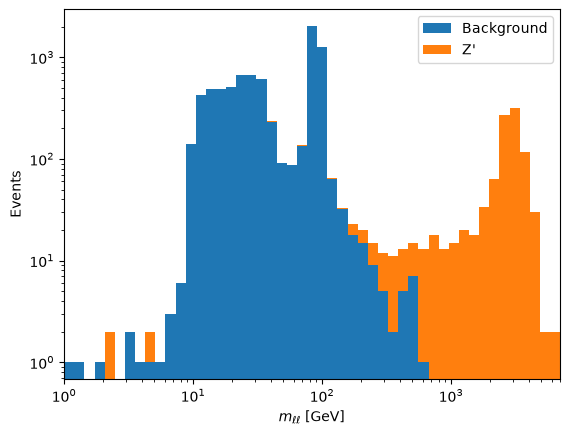

In [63]:
plot_variable(df_var, df_lab, "mass", 1, 7000, r"$m_{\ell\ell}$ [GeV]", "bb_mass.pdf", xlog=True, ylog=True)